# T1.4 crossed-pilot analysis — integrity, effect stability, and next gate

## tl;dr

- The retry-4 CUDA/P5000 run is operationally complete: all six jobs reached
  2,000 updates, the completion receipt is self-consistent, and this notebook
  re-hashes every receipt-bound output file before analysing it.
- On the 10-scenario selector bank, independently selected `O` checkpoints beat
  selected `O_bridge` checkpoints by **+2.78 percentage points on average**;
  at the common, non-selected update 2,000 horizon the difference is only
  **+0.56 points**. Replicate/opponent signs are mixed, so the pilot does not
  establish a stable safe-PBRS performance gain.
- The selector result is deliberately descriptive: each arm chose the best of
  41 checkpoints on these same 10 scenarios. The project statistics gate also
  rejects pooling the six per-job evaluation contracts, nested inference needs
  at least five model replicates, and `heuristic-rush` is absent.
- Therefore T1.4 training is complete, but its statistical exit gate remains
  open. The next admissible step is a new **joint, manifest-bound, non-sealed
  pilot evaluation** that includes the target `heuristic-rush` endpoint and
  produces the formal `statistics.json`; validation-B, sealed test, and reserve
  replicates remain untouched.

## Context & Methods

This is a diagnostic analysis report for the T1.4 `O` versus `O_bridge`
crossed pilot. Its decision is whether the completed training output is enough
to freeze the prospective T1.5 design.

### Key Assumptions

1. The canonical source is the retry-4 completion receipt and its bound files,
   not prose copied from an earlier status update.
2. Score rate is win=1, draw=0.5, loss=0. Both seats are averaged inside each
   scenario before any treatment difference is formed.
3. `selected` results describe the deployed checkpoint-selection procedure but
   are optimistically biased because the same 10 scenarios select the maximum
   among 41 updates. `final` means update 2,000 for every job and is included as
   a common-horizon sensitivity analysis.
4. The six validations are separate, completed job contracts. Their common
   scenario/opponent/seat coordinates permit a diagnostic reconstruction, but
   do not become a formal cross-arm statistics artifact by concatenation.
5. Only three model replicates exist. Power calculations below are sensitivity
   calculations, not precise estimates or an approval to launch T1.5.

No validation-B, sealed-test bank, or reserved replicate is read here. The
unpersisted 400-game `r1-O` versus historical `ppo-best` diagnostic is excluded
from every calculation.

### Reproduction

The notebook uses the repository `.venv`, project source, NumPy, and
Matplotlib. If the optional notebook stack is absent, install it locally with
`uv pip install --python .venv/bin/python nbformat nbclient ipykernel matplotlib`.
Rebuild with `python scripts/build_t14_pilot_analysis_notebook.py`, then execute
top-to-bottom with Jupyter/nbclient from the repository root. The source run
artifacts under `runs/task1-t14-crossed-pilot-20260915/pilot-retry-4/` must be
present; no remote data is fetched.

## Data

### 1. Load sources and define integrity helpers

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import platform
import sys
from collections import defaultdict
from pathlib import Path
from statistics import fmean, median, stdev

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

REPOSITORY = Path.cwd().resolve()
assert (REPOSITORY / "plan/task-1-2p-improvement-and-seed-protocol.md").is_file()
sys.path.insert(0, str(REPOSITORY / "src"))

from splendor.agents.our_agents.policy_imitation.protocol import (  # noqa: E402
    sha256_canonical_json,
)
from splendor.agents.our_agents.policy_imitation.statistics import (  # noqa: E402
    PowerAnalysisConfig,
    StatisticsError,
    method_differences,
    paired_power_analysis,
)

RUN_ROOT = REPOSITORY / "runs/task1-t14-crossed-pilot-20260915/pilot-retry-4"
TRAINING_ROOT = RUN_ROOT / "training"
COMPLETION_PATH = RUN_ROOT / "control/completion.json"
MANIFEST_PATH = RUN_ROOT / "manifest.json"
OUTPUT_JSON = REPOSITORY / "docs/task1/T1.4_PILOT_ANALYSIS_20260919.json"
OUTPUT_FIGURE = REPOSITORY / "docs/task1/T1.4_PILOT_ANALYSIS_20260919.png"

JOBS = tuple((replicate, treatment) for replicate in range(3) for treatment in ("O", "O_bridge"))
OPPONENTS = ("ga", "heuristic", "minimax")
ANALYSIS_MODES = ("selected", "final")


def load_json(path: Path) -> dict[str, object]:
    return json.loads(path.read_text(encoding="utf-8"))


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def markdown_table(headers: list[str], rows: list[list[object]]) -> str:
    lines = ["| " + " | ".join(headers) + " |", "|" + "|".join("---" for _ in headers) + "|"]
    lines.extend("| " + " | ".join(str(value) for value in row) + " |" for row in rows)
    return "\n".join(lines)


completion = load_json(COMPLETION_PATH)
manifest = load_json(MANIFEST_PATH)
assert completion["schema_version"] == "splendor-t14-pilot-completion/2"
completion_body = dict(completion)
completion_sha256 = str(completion_body.pop("completion_sha256"))
assert sha256_canonical_json(completion_body) == completion_sha256
assert manifest["lifecycle"][-1]["to"] == "completed"
assert completion_sha256 == "00f4305a36105004eccb53d4aef7199680296ee017f2b989a071bc85b8ff4d16"

environment = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
}
print(f"completion receipt: {completion_sha256}")
print(f"manifest lifecycle: {manifest['lifecycle'][-1]['to']}")
print(f"environment: {environment}")

completion receipt: 00f4305a36105004eccb53d4aef7199680296ee017f2b989a071bc85b8ff4d16
manifest lifecycle: completed
environment: {'python': '3.13.2', 'numpy': '1.26.4', 'matplotlib': '3.11.2'}


### 2. Re-hash the complete receipt and validate the six selected/final inputs

In [2]:
receipt_jobs = {
    (int(job["replicate_id"]), str(job["treatment_id"])): job
    for job in completion["jobs"]
}
assert set(receipt_jobs) == set(JOBS)

verified_file_count = 0
verified_bytes = 0
for job_key in JOBS:
    receipt_job = receipt_jobs[job_key]
    recorded_output_dir = Path(str(receipt_job["output_dir"]))
    output_dir = TRAINING_ROOT / recorded_output_dir.name
    assert recorded_output_dir.name == f"r{job_key[0]}-{job_key[1]}"
    assert output_dir.resolve().is_relative_to(TRAINING_ROOT.resolve())
    for relative_name, expected_sha256 in sorted(receipt_job["files"].items()):
        artifact_path = output_dir / relative_name
        assert artifact_path.is_file(), artifact_path
        actual_sha256 = sha256_file(artifact_path)
        assert actual_sha256 == expected_sha256, artifact_path
        verified_file_count += 1
        verified_bytes += artifact_path.stat().st_size

assert verified_file_count == 534

selections: dict[tuple[int, str], dict[str, object]] = {}
validation_documents: dict[tuple[str, int, str], dict[str, object]] = {}
records_by_mode: dict[str, list[dict[str, object]]] = {mode: [] for mode in ANALYSIS_MODES}

for replicate, treatment in JOBS:
    job_dir = TRAINING_ROOT / f"r{replicate}-{treatment}"
    selection = load_json(job_dir / "checkpoint-selection.json")
    selections[(replicate, treatment)] = selection
    assert selection["status"] == "completed"
    assert selection["replicate_id"] == replicate
    assert selection["treatment_id"] == treatment
    assert len(selection["evaluations"]) == 41

    selected_update = int(selection["selected_update"])
    for mode, update in (("selected", selected_update), ("final", 2000)):
        validation_path = job_dir / f"validation-update-{update}.json"
        validation = load_json(validation_path)
        validation_documents[(mode, replicate, treatment)] = validation
        audit = validation["paired_batch_audit"]
        assert validation["status"] == "valid"
        assert validation["update"] == update
        assert validation["scheduled_games"] == 60
        assert audit["status"] == "valid"
        assert audit["completed_games"] == 60
        assert audit["failed_games"] == 0
        assert audit["missing_games"] == 0
        for opponent_report in validation["reports"].values():
            assert opponent_report["games"] == 20
            assert opponent_report["completed_games"] == 20
            assert opponent_report["failed_games"] == 0
            records_by_mode[mode].extend(opponent_report["records"])

    selected_checkpoint = job_dir / f"update-{selected_update}.pth"
    assert sha256_file(selected_checkpoint) == selection["selected_checkpoint_sha256"]
    assert sha256_file(job_dir / "best.pth") == selection["best_sha256"]
    selected_evaluation = next(
        row for row in selection["evaluations"] if row["update"] == selected_update
    )
    selected_validation = validation_documents[("selected", replicate, treatment)]
    assert selected_evaluation["validation_evidence_sha256"] == selected_validation["evidence_sha256"]

assert len(records_by_mode["selected"]) == 360
assert len(records_by_mode["final"]) == 360

integrity_rows = [
    ["Completion schema", completion["schema_version"]],
    ["Receipt SHA-256", completion_sha256],
    ["Receipt-bound files re-hashed", verified_file_count],
    ["Receipt-bound bytes re-hashed", f"{verified_bytes:,}"],
    ["Jobs / updates", "6 / 2,000 each"],
    ["Selected records", len(records_by_mode["selected"])],
    ["Final-horizon records", len(records_by_mode["final"])],
]
display(Markdown(markdown_table(["Integrity check", "Observed"], integrity_rows)))

| Integrity check | Observed |
|---|---|
| Completion schema | splendor-t14-pilot-completion/2 |
| Receipt SHA-256 | 00f4305a36105004eccb53d4aef7199680296ee017f2b989a071bc85b8ff4d16 |
| Receipt-bound files re-hashed | 534 |
| Receipt-bound bytes re-hashed | 3,741,553,697 |
| Jobs / updates | 6 / 2,000 each |
| Selected records | 360 |
| Final-horizon records | 360 |

### 3. Audit the common semantic rectangle and formal-contract boundary

In [3]:
def record_coordinate(record: dict[str, object]) -> tuple[str, int]:
    return str(record["scenario_id"]), int(record["seat"])


semantic_sets: dict[tuple[str, int, str], set[tuple[str, str, int]]] = {}
model_seeds: dict[tuple[int, str], int] = {}
for mode in ANALYSIS_MODES:
    for replicate, treatment in JOBS:
        validation = validation_documents[(mode, replicate, treatment)]
        semantic_coordinates: set[tuple[str, str, int]] = set()
        candidate_metadata = None
        for opponent_id, report in validation["reports"].items():
            for record in report["records"]:
                semantic_coordinates.add((str(record["scenario_id"]), opponent_id, int(record["seat"])))
                candidate_metadata = record["candidate"]
        assert len(semantic_coordinates) == 60
        semantic_sets[(mode, replicate, treatment)] = semantic_coordinates
        seed = int(candidate_metadata["model_seed"])
        model_seeds[(replicate, treatment)] = seed

for mode in ANALYSIS_MODES:
    reference = semantic_sets[(mode, 0, "O")]
    assert all(
        semantic_sets[(mode, replicate, treatment)] == reference
        for replicate, treatment in JOBS
    )
    assert {scenario for scenario, _opponent, _seat in reference} == {
        scenario for scenario, _opponent, _seat in semantic_sets[(mode, 0, "O_bridge")]
    }

for replicate in range(3):
    assert model_seeds[(replicate, "O")] == model_seeds[(replicate, "O_bridge")]
assert len({model_seeds[(replicate, "O")] for replicate in range(3)}) == 3

formal_gate_error = None
try:
    method_differences(
        records_by_mode["selected"],
        treatment_id="O",
        control_treatment_id="O_bridge",
    )
except StatisticsError as error:
    formal_gate_error = str(error)

assert formal_gate_error == "episode rows mix evaluation contracts"
print("semantic matrix: 10 scenarios × 2 seats × 3 opponents × 6 jobs")
print(f"formal cross-arm gate: REJECTED ({formal_gate_error})")
print("interpretation: diagnostic reconstruction is allowed; formal method inference is not")

semantic matrix: 10 scenarios × 2 seats × 3 opponents × 6 jobs
formal cross-arm gate: REJECTED (episode rows mix evaluation contracts)
interpretation: diagnostic reconstruction is allowed; formal method inference is not


## Results

### 4. Compare selected checkpoints with the common update-2,000 horizon

In [4]:
def validation_score(validation: dict[str, object], opponent: str | None = None) -> float:
    if opponent is None:
        audit = validation["paired_batch_audit"]
        return float(audit["scheduled_score_numerator"]) / int(audit["scheduled_games"])
    report = validation["reports"][opponent]
    return (int(report["wins"]) + 0.5 * int(report["draws"])) / int(report["games"])


summary_by_mode: dict[str, list[dict[str, object]]] = {mode: [] for mode in ANALYSIS_MODES}
for mode in ANALYSIS_MODES:
    for replicate, treatment in JOBS:
        selection = selections[(replicate, treatment)]
        validation = validation_documents[(mode, replicate, treatment)]
        audit = validation["paired_batch_audit"]
        summary_by_mode[mode].append(
            {
                "replicate_id": replicate,
                "treatment_id": treatment,
                "update": int(validation["update"]),
                "wins": int(audit["wins"]),
                "draws": int(audit["draws"]),
                "losses": int(audit["losses"]),
                "score_rate": validation_score(validation),
                "ga": validation_score(validation, "ga"),
                "heuristic": validation_score(validation, "heuristic"),
                "minimax": validation_score(validation, "minimax"),
                "checkpoint_sha256": str(
                    selection["selected_checkpoint_sha256"]
                    if mode == "selected"
                    else next(
                        row["checkpoint_sha256"]
                        for row in selection["evaluations"]
                        if row["update"] == 2000
                    )
                ),
            }
        )

for mode in ANALYSIS_MODES:
    rows = [
        [
            f"r{row['replicate_id']}-{row['treatment_id']}",
            row["update"],
            f"{row['wins']}-{row['draws']}-{row['losses']}",
            f"{100 * row['score_rate']:.2f}%",
            f"{100 * row['ga']:.1f}%",
            f"{100 * row['heuristic']:.1f}%",
            f"{100 * row['minimax']:.1f}%",
        ]
        for row in summary_by_mode[mode]
    ]
    display(Markdown(f"**{mode.title()} checkpoint view**\n\n" + markdown_table(
        ["Job", "Update", "W-D-L", "Overall", "GA", "Heuristic", "Minimax"], rows
    )))

selected_o = fmean(row["score_rate"] for row in summary_by_mode["selected"] if row["treatment_id"] == "O")
selected_bridge = fmean(row["score_rate"] for row in summary_by_mode["selected"] if row["treatment_id"] == "O_bridge")
final_o = fmean(row["score_rate"] for row in summary_by_mode["final"] if row["treatment_id"] == "O")
final_bridge = fmean(row["score_rate"] for row in summary_by_mode["final"] if row["treatment_id"] == "O_bridge")

print(f"selected O - bridge: {100 * (selected_o - selected_bridge):+.2f} pp")
print(f"final@2000 O - bridge: {100 * (final_o - final_bridge):+.2f} pp")
print(f"selector uplift within O: {100 * (selected_o - final_o):+.2f} pp")
print(f"selector uplift within bridge: {100 * (selected_bridge - final_bridge):+.2f} pp")

**Selected checkpoint view**

| Job | Update | W-D-L | Overall | GA | Heuristic | Minimax |
|---|---|---|---|---|---|---|
| r0-O | 1650 | 42-0-18 | 70.00% | 70.0% | 65.0% | 75.0% |
| r0-O_bridge | 1950 | 42-0-18 | 70.00% | 70.0% | 70.0% | 70.0% |
| r1-O | 1850 | 45-0-15 | 75.00% | 70.0% | 75.0% | 80.0% |
| r1-O_bridge | 1950 | 41-0-19 | 68.33% | 60.0% | 70.0% | 75.0% |
| r2-O | 1900 | 43-0-17 | 71.67% | 85.0% | 65.0% | 65.0% |
| r2-O_bridge | 1600 | 42-0-18 | 70.00% | 75.0% | 60.0% | 75.0% |

**Final checkpoint view**

| Job | Update | W-D-L | Overall | GA | Heuristic | Minimax |
|---|---|---|---|---|---|---|
| r0-O | 2000 | 37-1-22 | 62.50% | 65.0% | 67.5% | 55.0% |
| r0-O_bridge | 2000 | 39-1-20 | 65.83% | 55.0% | 70.0% | 72.5% |
| r1-O | 2000 | 38-0-22 | 63.33% | 80.0% | 45.0% | 65.0% |
| r1-O_bridge | 2000 | 40-0-20 | 66.67% | 70.0% | 75.0% | 55.0% |
| r2-O | 2000 | 35-0-25 | 58.33% | 65.0% | 55.0% | 55.0% |
| r2-O_bridge | 2000 | 30-0-30 | 50.00% | 40.0% | 45.0% | 65.0% |

selected O - bridge: +2.78 pp
final@2000 O - bridge: +0.56 pp
selector uplift within O: +10.83 pp
selector uplift within bridge: +8.61 pp


### 5. Reconstruct paired scenario effects, with seats collapsed first

In [5]:
def diagnostic_differences(mode: str) -> list[dict[str, object]]:
    indexed: dict[tuple[int, str, str, str, int], float] = {}
    for record in records_by_mode[mode]:
        candidate = record["candidate"]
        key = (
            int(candidate["replicate_id"]),
            str(candidate["treatment_id"]),
            str(record["opponent"]["policy_id"]),
            str(record["scenario_id"]),
            int(record["seat"]),
        )
        assert key not in indexed
        indexed[key] = float(record["score_rate"])

    output: list[dict[str, object]] = []
    for replicate in range(3):
        for opponent in OPPONENTS:
            scenarios = sorted(
                scenario
                for candidate_replicate, treatment, candidate_opponent, scenario, seat in indexed
                if candidate_replicate == replicate
                and treatment == "O"
                and candidate_opponent == opponent
                and seat == 0
            )
            assert len(scenarios) == 10
            for scenario in scenarios:
                o_score = fmean(indexed[(replicate, "O", opponent, scenario, seat)] for seat in (0, 1))
                bridge_score = fmean(indexed[(replicate, "O_bridge", opponent, scenario, seat)] for seat in (0, 1))
                output.append(
                    {
                        "replicate_id": replicate,
                        "opponent_id": opponent,
                        "scenario_id": scenario,
                        "o_score_rate": o_score,
                        "bridge_score_rate": bridge_score,
                        "difference": o_score - bridge_score,
                    }
                )
    assert len(output) == 90
    return output


diagnostic_effects = {mode: diagnostic_differences(mode) for mode in ANALYSIS_MODES}


def method_effect_summary(rows: list[dict[str, object]]) -> dict[str, object]:
    by_replicate_opponent: dict[tuple[int, str], list[float]] = defaultdict(list)
    for row in rows:
        by_replicate_opponent[(int(row["replicate_id"]), str(row["opponent_id"]))].append(float(row["difference"]))
    cells = {key: fmean(values) for key, values in by_replicate_opponent.items()}
    replicate_means = {
        replicate: fmean(cells[(replicate, opponent)] for opponent in OPPONENTS)
        for replicate in range(3)
    }
    endpoint_means = {
        opponent: fmean(cells[(replicate, opponent)] for replicate in range(3))
        for opponent in OPPONENTS
    }
    return {
        "replicate_by_opponent": {
            f"r{replicate}:{opponent}": cells[(replicate, opponent)]
            for replicate in range(3)
            for opponent in OPPONENTS
        },
        "replicate_means": {f"r{replicate}": value for replicate, value in replicate_means.items()},
        "endpoint_means": endpoint_means,
        "mean_difference": fmean(replicate_means.values()),
        "between_replicate_sample_sd": stdev(replicate_means.values()),
        "worst_replicate": min(replicate_means.values()),
    }


effect_summaries = {mode: method_effect_summary(rows) for mode, rows in diagnostic_effects.items()}
effect_table = []
for mode in ANALYSIS_MODES:
    cells = effect_summaries[mode]["replicate_by_opponent"]
    for replicate in range(3):
        effect_table.append(
            [
                mode,
                f"r{replicate}",
                f"{100 * cells[f'r{replicate}:ga']:+.1f}",
                f"{100 * cells[f'r{replicate}:heuristic']:+.1f}",
                f"{100 * cells[f'r{replicate}:minimax']:+.1f}",
                f"{100 * effect_summaries[mode]['replicate_means'][f'r{replicate}']:+.2f}",
            ]
        )
display(Markdown(markdown_table(
    ["View", "Replicate", "GA (pp)", "Heuristic (pp)", "Minimax (pp)", "Overall (pp)"],
    effect_table,
)))

for mode in ANALYSIS_MODES:
    summary = effect_summaries[mode]
    print(
        f"{mode}: mean={100 * summary['mean_difference']:+.2f} pp, "
        f"between-replicate SD={100 * summary['between_replicate_sample_sd']:.2f} pp, "
        f"worst={100 * summary['worst_replicate']:+.2f} pp"
    )

| View | Replicate | GA (pp) | Heuristic (pp) | Minimax (pp) | Overall (pp) |
|---|---|---|---|---|---|
| selected | r0 | +0.0 | -5.0 | +5.0 | +0.00 |
| selected | r1 | +10.0 | +5.0 | +5.0 | +6.67 |
| selected | r2 | +10.0 | +5.0 | -10.0 | +1.67 |
| final | r0 | +10.0 | -2.5 | -17.5 | -3.33 |
| final | r1 | +10.0 | -30.0 | +10.0 | -3.33 |
| final | r2 | +25.0 | +10.0 | -10.0 | +8.33 |

selected: mean=+2.78 pp, between-replicate SD=3.47 pp, worst=+0.00 pp
final: mean=+0.56 pp, between-replicate SD=6.74 pp, worst=-3.33 pp


### 6. Decompose balanced-grid variation as a design diagnostic

In [6]:
def variance_decomposition(mode: str, treatment: str) -> dict[str, object]:
    records = [
        record
        for record in records_by_mode[mode]
        if record["candidate"]["treatment_id"] == treatment
    ]
    replicates = sorted({int(record["candidate"]["replicate_id"]) for record in records})
    scenarios = sorted({str(record["scenario_id"]) for record in records})
    opponents = sorted({str(record["opponent"]["policy_id"]) for record in records})
    seats = [0, 1]
    shape = (len(replicates), len(scenarios), len(seats), len(opponents))
    values = np.empty(shape, dtype=np.float64)
    replicate_index = {value: index for index, value in enumerate(replicates)}
    scenario_index = {value: index for index, value in enumerate(scenarios)}
    opponent_index = {value: index for index, value in enumerate(opponents)}
    for record in records:
        values[
            replicate_index[int(record["candidate"]["replicate_id"])],
            scenario_index[str(record["scenario_id"])],
            int(record["seat"]),
            opponent_index[str(record["opponent"]["policy_id"])],
        ] = float(record["score_rate"])

    grand = float(values.mean())
    effects = {
        "model_replicate": values.mean(axis=(1, 2, 3)) - grand,
        "scenario": values.mean(axis=(0, 2, 3)) - grand,
        "seat": values.mean(axis=(0, 1, 3)) - grand,
        "opponent": values.mean(axis=(0, 1, 2)) - grand,
    }
    fitted = (
        grand
        + effects["model_replicate"][:, None, None, None]
        + effects["scenario"][None, :, None, None]
        + effects["seat"][None, None, :, None]
        + effects["opponent"][None, None, None, :]
    )
    energies = {
        "model_replicate": float(np.mean(effects["model_replicate"] ** 2)),
        "scenario": float(np.mean(effects["scenario"] ** 2)),
        "seat": float(np.mean(effects["seat"] ** 2)),
        "opponent": float(np.mean(effects["opponent"] ** 2)),
        "interaction_residual": float(np.mean((values - fitted) ** 2)),
    }
    total = float(np.mean((values - grand) ** 2))
    assert math.isclose(sum(energies.values()), total, rel_tol=0.0, abs_tol=1e-12)
    return {
        "population_total_variance": total,
        "energies": energies,
        "shares": {name: value / total for name, value in energies.items()},
        "design": {
            "replicates": len(replicates),
            "scenarios": len(scenarios),
            "seats": len(seats),
            "opponents": len(opponents),
        },
    }


variance_results = {
    mode: {treatment: variance_decomposition(mode, treatment) for treatment in ("O", "O_bridge")}
    for mode in ANALYSIS_MODES
}
variance_rows = []
for mode in ANALYSIS_MODES:
    for treatment in ("O", "O_bridge"):
        result = variance_results[mode][treatment]
        shares = result["shares"]
        variance_rows.append(
            [
                mode,
                treatment,
                f"{result['population_total_variance']:.6f}",
                f"{100 * shares['model_replicate']:.2f}%",
                f"{100 * shares['scenario']:.2f}%",
                f"{100 * shares['seat']:.2f}%",
                f"{100 * shares['opponent']:.2f}%",
                f"{100 * shares['interaction_residual']:.2f}%",
            ]
        )
display(Markdown(markdown_table(
    ["View", "Arm", "Total var", "Model", "Scenario", "Seat", "Opponent", "Interaction"],
    variance_rows,
)))

print("These are finite-grid energies, not Gaussian random-effect estimates.")
print("The selected view is additionally contaminated by best-of-41 selector reuse.")

| View | Arm | Total var | Model | Scenario | Seat | Opponent | Interaction |
|---|---|---|---|---|---|---|---|
| selected | O | 0.200617 | 0.22% | 4.92% | 0.06% | 0.40% | 94.40% |
| selected | O_bridge | 0.212191 | 0.03% | 1.82% | 0.36% | 0.38% | 97.41% |
| final | O | 0.235640 | 0.20% | 5.40% | 0.27% | 1.62% | 92.51% |
| final | O_bridge | 0.236875 | 2.48% | 7.72% | 3.55% | 0.72% | 85.53% |

These are finite-grid energies, not Gaussian random-effect estimates.
The selected view is additionally contaminated by best-of-41 selector reuse.


### 7. Run power sensitivity without crossing the formal approval gate

In [7]:
def endpoint_replicate_values(mode: str, opponent: str) -> list[float]:
    cells = effect_summaries[mode]["replicate_by_opponent"]
    return [float(cells[f"r{replicate}:{opponent}"]) for replicate in range(3)]


power_sensitivity: dict[str, dict[str, dict[str, object]]] = {}
for mode in ANALYSIS_MODES:
    power_sensitivity[mode] = {}
    for delta in (0.03, 0.05):
        delta_key = f"delta_{int(delta * 100):02d}pp"
        power_sensitivity[mode][delta_key] = {}
        for opponent in OPPONENTS:
            config = PowerAnalysisConfig(
                unit="model_replicate",
                minimum_effect=delta,
                familywise_alpha=0.05,
                family_size=2,
                target_power=0.8,
                max_n=50,
                round_to=1,
                simulations=10_000,
                seed=20_260_919,
            )
            power_sensitivity[mode][delta_key][opponent] = paired_power_analysis(
                endpoint_replicate_values(mode, opponent), config
            )

power_rows = []
for mode in ANALYSIS_MODES:
    for delta_key in ("delta_03pp", "delta_05pp"):
        for opponent in OPPONENTS:
            result = power_sensitivity[mode][delta_key][opponent]
            power_rows.append(
                [
                    mode,
                    delta_key.replace("delta_", "").replace("pp", " pp"),
                    opponent,
                    f"{100 * result['paired_sample_sd']:.2f} pp",
                    result["recommended_n"],
                    f"{100 * result['simulated_power_at_recommended_n']:.1f}%",
                    "yes" if result["underpowered"] else "no",
                ]
            )
display(Markdown(markdown_table(
    ["View", "Minimum effect", "Endpoint", "Pilot SD", "Recommended reps", "Power", "Capped/underpowered"],
    power_rows,
)))

print("Family size is fixed at two to mirror a two-endpoint family; only one targeted endpoint (heuristic) is present.")
print("Because heuristic-rush is missing and n=3, these values cannot determine the formal family maximum or approve N.")

| View | Minimum effect | Endpoint | Pilot SD | Recommended reps | Power | Capped/underpowered |
|---|---|---|---|---|---|---|
| selected | 03 pp | ga | 5.77 pp | 30 | 91.1% | no |
| selected | 03 pp | heuristic | 5.77 pp | 30 | 91.1% | no |
| selected | 03 pp | minimax | 8.66 pp | 50 | 80.3% | no |
| selected | 05 pp | ga | 5.77 pp | 11 | 87.2% | no |
| selected | 05 pp | heuristic | 5.77 pp | 11 | 87.2% | no |
| selected | 05 pp | minimax | 8.66 pp | 24 | 93.5% | no |
| final | 03 pp | ga | 8.66 pp | 50 | 89.8% | no |
| final | 03 pp | heuristic | 20.46 pp | 50 | 25.6% | yes |
| final | 03 pp | minimax | 14.22 pp | 50 | 41.5% | yes |
| final | 05 pp | ga | 8.66 pp | 24 | 97.9% | no |
| final | 05 pp | heuristic | 20.46 pp | 50 | 54.7% | yes |
| final | 05 pp | minimax | 14.22 pp | 50 | 87.8% | no |

Family size is fixed at two to mirror a two-endpoint family; only one targeted endpoint (heuristic) is present.
Because heuristic-rush is missing and n=3, these values cannot determine the formal family maximum or approve N.


### 8. Visualize trajectory crossings and replicate-level effects

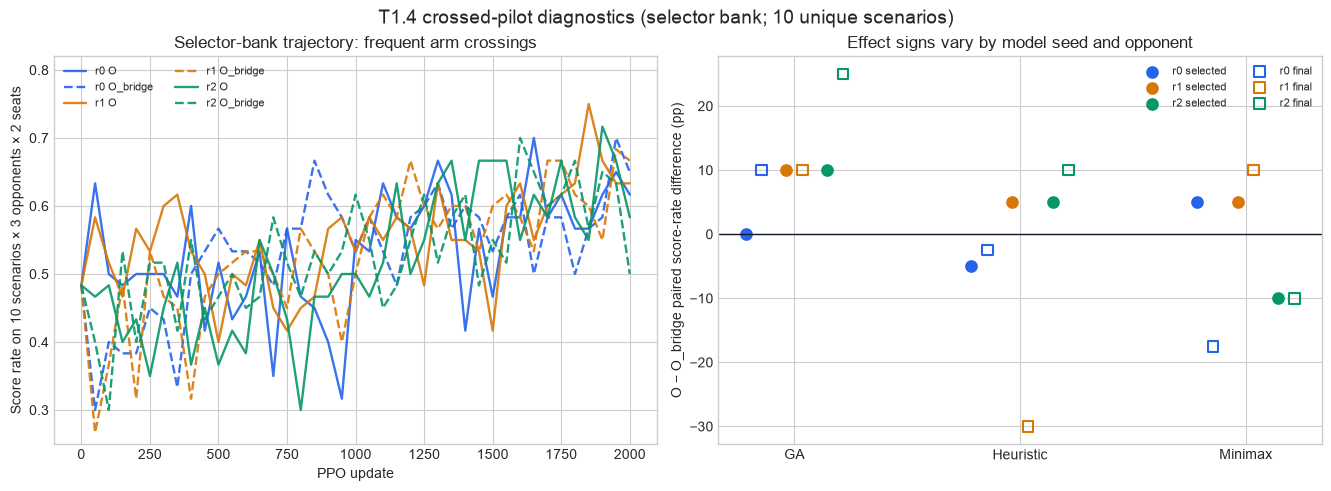

saved figure: docs/task1/T1.4_PILOT_ANALYSIS_20260919.png


In [8]:
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {0: "#2563eb", 1: "#d97706", 2: "#059669"}

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8), constrained_layout=True)

for replicate in range(3):
    for treatment, linestyle in (("O", "-"), ("O_bridge", "--")):
        evaluations = selections[(replicate, treatment)]["evaluations"]
        updates = [int(row["update"]) for row in evaluations]
        score_rates = [int(row["total_integer_wins"]) / int(row["scheduled_games"]) for row in evaluations]
        axes[0].plot(
            updates,
            score_rates,
            color=COLORS[replicate],
            linestyle=linestyle,
            linewidth=1.7,
            alpha=0.9,
            label=f"r{replicate} {treatment}",
        )
axes[0].set_title("Selector-bank trajectory: frequent arm crossings")
axes[0].set_xlabel("PPO update")
axes[0].set_ylabel("Score rate on 10 scenarios × 3 opponents × 2 seats")
axes[0].set_ylim(0.25, 0.82)
axes[0].legend(ncol=2, fontsize=8, frameon=False)

x_positions = np.arange(len(OPPONENTS))
offsets = {0: -0.18, 1: 0.0, 2: 0.18}
markers = {"selected": "o", "final": "s"}
for mode in ANALYSIS_MODES:
    for replicate in range(3):
        values = [
            100 * effect_summaries[mode]["replicate_by_opponent"][f"r{replicate}:{opponent}"]
            for opponent in OPPONENTS
        ]
        jitter = offsets[replicate] + (-0.035 if mode == "selected" else 0.035)
        axes[1].scatter(
            x_positions + jitter,
            values,
            color=COLORS[replicate],
            marker=markers[mode],
            s=58,
            facecolors=COLORS[replicate] if mode == "selected" else "none",
            linewidths=1.5,
            label=f"r{replicate} {mode}",
        )
axes[1].axhline(0, color="#111827", linewidth=1)
axes[1].set_xticks(x_positions, ["GA", "Heuristic", "Minimax"])
axes[1].set_ylabel("O − O_bridge paired score-rate difference (pp)")
axes[1].set_title("Effect signs vary by model seed and opponent")
axes[1].legend(ncol=2, fontsize=8, frameon=False)

fig.suptitle("T1.4 crossed-pilot diagnostics (selector bank; 10 unique scenarios)", fontsize=14)
fig.savefig(OUTPUT_FIGURE, dpi=180, bbox_inches="tight")
plt.show()

print(f"saved figure: {OUTPUT_FIGURE.relative_to(REPOSITORY)}")

### 9. Persist the machine-readable diagnostic summary

In [9]:
trajectory_diagnostics: dict[str, dict[str, object]] = {}
for replicate in range(3):
    o_evaluations = {int(row["update"]): int(row["total_integer_wins"]) for row in selections[(replicate, "O")]["evaluations"]}
    bridge_evaluations = {int(row["update"]): int(row["total_integer_wins"]) for row in selections[(replicate, "O_bridge")]["evaluations"]}
    assert set(o_evaluations) == set(bridge_evaluations)
    win_differences = [o_evaluations[update] - bridge_evaluations[update] for update in sorted(o_evaluations)]
    trajectory_diagnostics[f"r{replicate}"] = {
        "checkpoints": len(win_differences),
        "o_mean_wins": fmean(o_evaluations.values()),
        "bridge_mean_wins": fmean(bridge_evaluations.values()),
        "mean_win_difference": fmean(win_differences),
        "median_win_difference": median(win_differences),
        "positive_tie_negative": [
            sum(value > 0 for value in win_differences),
            sum(value == 0 for value in win_differences),
            sum(value < 0 for value in win_differences),
        ],
        "minimum_win_difference": min(win_differences),
        "maximum_win_difference": max(win_differences),
    }

analysis_body: dict[str, object] = {
    "schema_version": "splendor-t14-pilot-diagnostic-analysis/1",
    "analysis_date": "2026-09-19",
    "source": {
        "completion_path": str(COMPLETION_PATH.relative_to(REPOSITORY)),
        "completion_sha256": completion_sha256,
        "manifest_declaration_sha256": completion["declaration_sha256"],
        "validation_bank_payload_sha256": completion["validation_bank_payload_sha256"],
    },
    "environment": environment,
    "integrity": {
        "receipt_self_hash_valid": True,
        "manifest_terminal_state": manifest["lifecycle"][-1]["to"],
        "receipt_bound_files_verified": verified_file_count,
        "receipt_bound_bytes_verified": verified_bytes,
        "jobs": len(JOBS),
        "updates_per_job": 2000,
        "selected_and_final_batches_valid": True,
    },
    "design": {
        "replicates": 3,
        "treatments": ["O", "O_bridge"],
        "selector_scenarios": 10,
        "seats": [0, 1],
        "opponents": list(OPPONENTS),
        "checkpoints_per_job": 41,
        "formal_cross_arm_gate": "rejected",
        "formal_cross_arm_gate_error": formal_gate_error,
        "missing_target_endpoint": "heuristic-rush",
        "nested_inference_minimum_replicates": 5,
    },
    "checkpoint_views": summary_by_mode,
    "diagnostic_method_effects": effect_summaries,
    "trajectory_diagnostics": trajectory_diagnostics,
    "variance_decomposition": variance_results,
    "power_sensitivity": power_sensitivity,
    "decision": {
        "training_status": "complete",
        "t14_statistical_exit_gate": "not-satisfied",
        "safe_pbrs_performance_claim": "not-established",
        "next_required_step": "joint-manifest-bound-nonsealed-pilot-evaluation",
        "required_endpoint_addition": "heuristic-rush",
        "validation_b_consumed": False,
        "sealed_consumed": False,
        "reserve_replicates_activated": False,
    },
    "limitations": [
        "Selected checkpoints maximize the same 10-scenario selector bank over 41 updates.",
        "Only three model replicates are available.",
        "Per-job validation contracts cannot be concatenated into a formal method contrast.",
        "The heuristic-rush target endpoint is absent.",
        "The unpersisted 400-game r1-O versus ppo-best diagnostic is excluded.",
    ],
}
analysis_document = dict(analysis_body)
analysis_document["analysis_sha256"] = sha256_canonical_json(analysis_body)
OUTPUT_JSON.write_text(json.dumps(analysis_document, indent=2, sort_keys=True) + "\n", encoding="utf-8")

print(f"analysis SHA-256: {analysis_document['analysis_sha256']}")
print(f"saved summary: {OUTPUT_JSON.relative_to(REPOSITORY)}")

analysis SHA-256: 7aab17619269a92552517696f5f8efdb21cf1e210147f26a13765da16ed76647
saved summary: docs/task1/T1.4_PILOT_ANALYSIS_20260919.json


## Takeaways

1. **Operational result:** retry-4 is a valid completed training run, not a
   partial or orphaned output. The complete receipt and all 534 bound files were
   re-hashed successfully.
2. **Scientific result:** `O` is not uniformly better than `O_bridge`. The
   selected-checkpoint average is +2.78 pp, but the common update-2,000 average
   is +0.56 pp and several replicate/opponent cells reverse sign. This supports
   the correctness of keeping the reward contracts distinct; it does not prove
   a performance improvement from safe terminal handling.
3. **Selection warning:** the selector adds roughly nine to ten points to each
   arm relative to its update-2,000 score on the same tiny bank. `r1-O`'s 45/60
   is a shortlist signal, not an independent generalization estimate.
4. **Power warning:** three model seeds give unstable variance estimates. The
   3 pp sensitivity generally asks for dozens of replicates and, at the final
   horizon, some endpoints remain underpowered even at the 50-replicate cap.
   Five replicates can therefore be a resource-limited confirmatory design only
   if the report explicitly declines a 3 pp high-power method claim.
5. **Decision:** do not approve T1.5 from these six job artifacts alone. First
   create a joint non-sealed pilot-evaluation manifest with one evaluation
   contract, frozen candidates, `heuristic` + `heuristic-rush` superiority
   endpoints, GA/minimax guardrails, and a formal statistics artifact. Only
   after reviewing that immutable proposal should the human approval transition
   occur. No validation-B, sealed bank, or reserve replicate should be touched.